In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [5]:
import os
os.listdir('/kaggle/input/competitions/digit-recognizer')

['sample_submission.csv', 'train.csv', 'test.csv']

In [6]:
data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [7]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
data = np.array(data)
# chia dataset nếu dùng sklearn sẽ có train_test_split, làm chay thì ko
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T # chuyển vị hàng thành cột, lấy 1k làm ví dụ
Y_dev = data_dev[0] # đây là label
X_dev = data_dev[1:n] / 255.0 # còn đây là feature, chia để normalize pixel về 0-1

data_train = data[1000:m].T # Phần còn lại của dataset
Y_train = data_train[0]
X_train = data_train[1:n] / 255.0

In [9]:
Y_train

array([7, 5, 5, ..., 2, 6, 4])

In [10]:
X_train[:,0].shape

(784,)

In [ ]:
def init_params(): # initializer
    W1 = np.random.rand(10, 784) - 0.5 # Tạo trọng số random sau đó mô hình sẽ sửa lại
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

In [ ]:
def Relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def foward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = Relu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def onehot(Y):
    # Tạo ma trận toàn 0 với size của Y và số lượng phần tử trong Y
    # max của Y là 9 do dataset toàn số 0 đến 9 + 1 = 10 -> số lượng phần tử thật
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    # Đại khái là lặp qua toàn bộ ma trận Y, rồi đến phần tử thứ Y thì đặt nó bằng 1
    # -> Tạo one hot vector
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def deriv_relu(Z):
    # vì cách hoạt động của ReLU là mọi phần tử đều là 0 hoặc >= 0
    # n+332ên nếu Z > 0 thì là true = 1, false = 0
    # còn thắc mắc tại sao đạo hàm mà lại chỉ đi check thế này
    # thì học lại giải tích
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = onehot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * dZ2.dot(A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = W2.T.dot(dZ2) * deriv_relu(Z1)
    dW1 = (1 / m) * dZ1.dot(X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    return W1, b1, W2, b2

In [ ]:
def get_predict(A2):
    return np.argmax(A2, 0)

def get_accu(predict, Y):
    print(predict, Y)
    return np.sum(predict == Y) / Y.size

def gradient_descent(X, Y, iter, learning_rate):
    W1, b1, W2, b2 = init_params()
    for i in range(iter):
        Z1, A1, Z2, A2 = foward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)
        if i % 10 == 0:
            print("Iteration: ", i)
            print("Accuracy :", get_accu(get_predict(A2),Y))

    return W1, b1, W2, b2

In [ ]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)

Iteration:  0
[7 7 1 ... 1 5 5] [7 5 5 ... 2 6 4]
Accuracy : 0.07609756097560975
Iteration:  10
[7 3 1 ... 0 5 5] [7 5 5 ... 2 6 4]
Accuracy : 0.24436585365853658
Iteration:  20
[7 3 1 ... 0 5 5] [7 5 5 ... 2 6 4]
Accuracy : 0.33670731707317075
Iteration:  30
[7 3 8 ... 8 5 7] [7 5 5 ... 2 6 4]
Accuracy : 0.401219512195122
Iteration:  40
[7 3 6 ... 8 5 7] [7 5 5 ... 2 6 4]
Accuracy : 0.44714634146341464
Iteration:  50
[7 3 6 ... 2 5 7] [7 5 5 ... 2 6 4]
Accuracy : 0.48897560975609755
Iteration:  60
[7 3 6 ... 2 6 9] [7 5 5 ... 2 6 4]
Accuracy : 0.5271463414634147
Iteration:  70
[9 3 6 ... 2 6 9] [7 5 5 ... 2 6 4]
Accuracy : 0.5603170731707318
Iteration:  80
[9 3 6 ... 2 6 9] [7 5 5 ... 2 6 4]
Accuracy : 0.5899756097560975
Iteration:  90
[9 3 6 ... 2 6 9] [7 5 5 ... 2 6 4]
Accuracy : 0.6155121951219512
Iteration:  100
[9 3 6 ... 2 6 9] [7 5 5 ... 2 6 4]
Accuracy : 0.6378780487804878
Iteration:  110
[9 3 6 ... 2 6 9] [7 5 5 ... 2 6 4]
Accuracy : 0.6555609756097561
Iteration:  120
[9 3 5 

In [ ]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = foward_prop(W1, b1, W2, b2, X)
    predictions = get_predict(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [9]
Label:  7


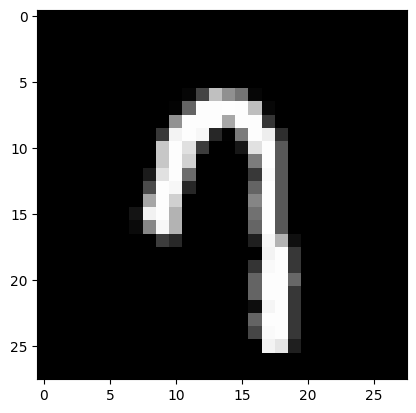

Prediction:  [5]
Label:  5


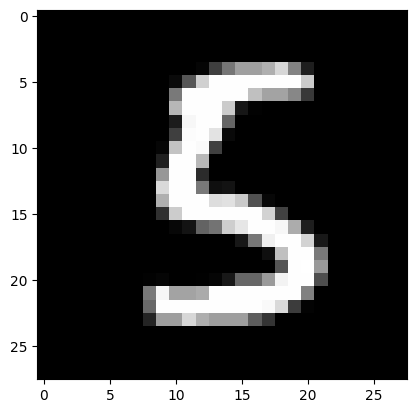

Prediction:  [5]
Label:  5


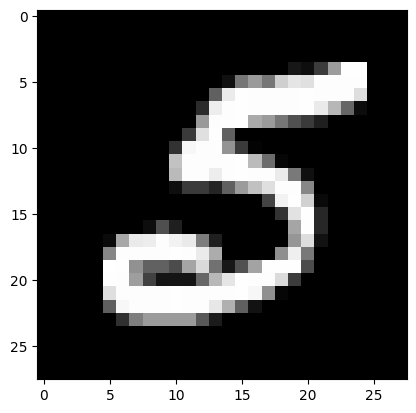

Prediction:  [4]
Label:  4


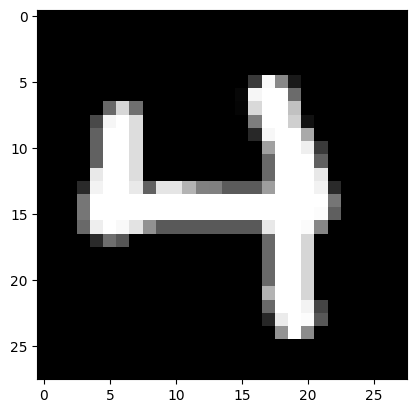

In [ ]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

Image number:  34683
Prediction:  [5]
Label:  8


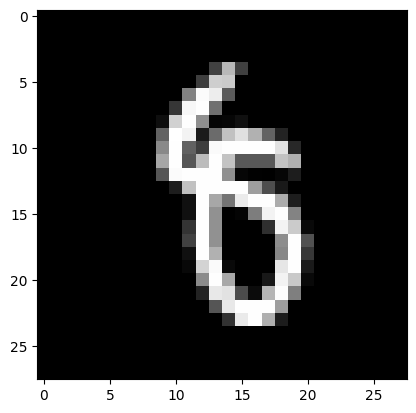

In [ ]:
import random
num = random.randint(0, X_train.shape[1] - 1) # 34683

print("Image number: ", num)
test_prediction(num, W1, b1, W2, b2)

In [ ]:
# Thử lại với dev (test) dataset
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accu(dev_predictions, Y_dev)

[2 3 1 7 1 0 4 6 2 9 1 2 7 7 8 9 6 2 8 0 3 1 9 8 8 8 9 5 2 3 1 1 7 8 6 9 6
 4 1 5 9 6 8 0 3 6 6 5 2 9 4 0 3 9 9 3 9 4 1 6 3 6 7 6 5 4 6 1 9 8 0 7 6 7
 8 6 9 8 4 0 9 9 4 6 9 6 2 8 0 6 7 8 5 9 9 9 9 0 5 5 3 9 2 0 2 5 9 3 9 1 0
 5 8 9 5 0 7 9 9 9 2 5 3 8 8 4 7 1 3 0 8 3 8 2 8 9 2 7 4 8 0 9 7 3 5 0 5 3
 5 5 4 1 7 9 2 9 3 9 5 5 1 4 0 3 1 7 4 1 4 4 1 5 3 7 7 6 3 8 8 6 3 2 0 1 9
 2 8 2 3 3 0 5 1 6 1 8 3 1 2 8 0 5 4 3 4 3 0 5 2 1 4 3 0 5 5 6 3 9 5 4 2 9
 7 9 5 0 1 7 5 0 8 5 9 2 1 1 2 6 9 6 6 7 3 7 6 3 8 2 4 9 2 8 6 9 2 3 9 1 8
 2 8 2 3 8 9 7 7 6 4 5 6 7 9 3 2 9 4 8 2 4 3 2 4 7 8 2 6 4 4 5 0 1 7 3 0 8
 5 2 6 3 0 6 6 5 1 8 3 9 3 1 1 4 9 7 2 3 1 4 3 0 1 0 9 4 5 4 2 4 9 7 2 7 2
 7 5 2 4 8 7 6 7 8 5 4 7 3 0 6 2 3 1 1 3 6 3 2 2 4 5 2 3 1 8 4 0 9 7 5 0 9
 7 4 0 2 5 1 5 0 3 0 4 7 8 1 4 0 8 5 4 3 1 6 1 1 8 2 4 3 4 5 6 8 8 2 8 9 8
 3 4 8 9 0 6 3 4 2 6 3 9 1 5 1 9 0 3 4 9 1 6 3 7 5 7 6 8 8 9 7 8 8 5 7 2 8
 1 6 2 5 6 6 5 5 6 2 1 4 1 1 2 1 8 3 7 4 2 4 9 2 4 2 6 3 4 6 0 1 8 2 7 1 1
 1 4 9 5 9 9 8 6 8 6 5 5 

np.float64(0.843)

Vẫn đc 84.3% -> Tương đối khớp với độ chính xác ban đầu